# Results NVV-Pipeline Evaluation Experiment - Full-GT and Part-GT
- yml: environment.yml
- env: nvv_isolation_pipeline
- last updated: 05.04.2026


## RQ - Experiment Mapping Table
| RQ | Experiment | Full-GT Mode | Part-GT Mode | Result |
|---|---|---|---|---|
| RQ1 Capability | Baseline vs. best configuration set | Greedy forward selection + union evaluation (F1-based) | Reuse of selected set + union evaluation | Best achievable score vs. baseline |
| RQ2 Sensitivity | Configuration ranking (single best) | Ranking based on full-GT metrics | Ranking based on part-GT metrics | Best single configuration |
|  | Configuration combination (selected set) | Greedy forward selection + union evaluation | Reuse of selected set + union evaluation | Best-performing configuration set |
|  | Audio derivative aggregation | Group-wise comparison by ASR input audio derivative | Distribution-based comparison across groups | Best-performing audio derivative group |
| RQ3 NVV Coverage | Coverage analysis | Global and label-level analysis | Global and Event-level analysis | Coverage across categories or events |

## Setup
- Imports
- Config

In [1]:
#Setup
import os
import sys
from pathlib import Path

project_root = Path(os.getcwd()).parent
sys.path.append(str(project_root))
results_dir = project_root / "data" / "results"

import pandas as pd
import matplotlib.pyplot as plt

from config.load_config import load_config
from config.path_factory import print_paths

from evaluation.analysis_loader import load_and_compare_workspaces
from evaluation.analysis_tables import build_rq1_capability_tables


cfg_path_nvs_full_gt = project_root / "experiments" / "pipeline_evaluation" / "config_nvs38k_full_gt.yaml"
cfg_path_nvs_part_gt = project_root / "experiments" / "pipeline_evaluation" / "config_nvs38k_part_gt.yaml"
cfg_path_vocal_part_gt = project_root / "experiments" / "pipeline_evaluation" / "config_vocal_part_gt.yaml"

rq_results_dir = results_dir

config = load_config(cfg_path_nvs_full_gt)
print_paths(cfg_path_nvs_full_gt)


NVV PATH CONFIG PRINT

[PROJECT]
  cfg_path:       /home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/experiments/pipeline_evaluation/config_nvs38k_full_gt.yaml
  project_root:   /home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline
  raw_root:       /home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/raw
  processed_root: /home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/processed/NVS-38K_EN

[PIPELINE WORKSPACES]

  - NVS-38K_EN
      input_dir:  /home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/raw/experiment_pipeline_evaluation/NVS-38K_EN
      workspace:  /home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/processed/NVS-38K_EN/NVS-38K_EN
      evaluation: /home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipel

## Collect Pipeline Evaluation Experiment Results 
- Experiment specs for comparison


In [2]:
# specification of full run evaluation experiments to load and compare (all settings)
specs = [
    {
        "label": "NVS-38K_EN | full_gt",
        "cfg_path": cfg_path_nvs_full_gt,
        "dataset_name": "NVS-38K_EN",
        "mode": "full_gt",
    },
    {
        "label": "NVS-38K_EN | part_gt",
        "cfg_path": cfg_path_nvs_part_gt,
        "dataset_name": "NVS-38K_EN",
        "mode": "part_gt",
    },
    {
        "label": "VOCAL_RA1 | part_gt",
        "cfg_path": cfg_path_vocal_part_gt,
        "dataset_name": "VOCAL_RA1",
        "mode": "part_gt",
    },
    {
        "label": "VOCAL_RA2 | part_gt",
        "cfg_path": cfg_path_vocal_part_gt,
        "dataset_name": "VOCAL_RA2",
        "mode": "part_gt",
    },
]

analysis_bundle = load_and_compare_workspaces(
    specs=specs,
    param_names=[],
    param_pairs=[],
)

bundles_by_spec = analysis_bundle["bundles_by_spec"]
views_by_spec = analysis_bundle["views_by_spec"]
views = analysis_bundle["combined_views"]
setting_order = analysis_bundle["setting_order"]

bundles_by_spec.keys()


dict_keys(['NVS-38K_EN | full_gt', 'NVS-38K_EN | part_gt', 'VOCAL_RA1 | part_gt', 'VOCAL_RA2 | part_gt'])

## RQ1 Pipeline Capability

In [3]:

# RQ1 Pipeline Capability
# --- collect RQ1 tables from the loaded settings ---
rq1_all = pd.concat(
    [
        bundle["results"]["rq1"]
        for bundle in analysis_bundle["bundles_by_spec"].values()
    ],
    ignore_index=True,
)

rq1_tables = build_rq1_capability_tables(rq1_all)

print("RQ1 Capability Table (Full-GT):")
display(rq1_tables["full_gt"])

print("RQ1 Capability Table (Part-GT):")
display(rq1_tables["part_gt"])

RQ1 Capability Table (Full-GT):


,Setting,System,F1,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,NVS-38K_EN | full_gt,Baseline,0.158532,0.230898,0.203614,0.203614,1.520915
1,NVS-38K_EN | full_gt,Best Selected Set,0.198103,0.270496,0.237039,0.237039,1.517568
2,NVS-38K_EN | full_gt,Δ vs Baseline,0.039571,0.039598,0.033425,0.033425,-0.003346


RQ1 Capability Table (Part-GT):


,Setting,System,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,NVS-38K_EN | part_gt,Baseline,0.230898,0.203614,0.203614,1.520915
1,NVS-38K_EN | part_gt,Best Selected Set,0.270496,0.237039,0.237039,1.517568
2,NVS-38K_EN | part_gt,Δ vs Baseline,0.039598,0.033425,0.033425,-0.003346
3,VOCAL_RA1 | part_gt,Baseline,0.199631,0.178218,0.357947,1.845932
4,VOCAL_RA1 | part_gt,Best Selected Set,0.274072,0.240137,0.458683,3.098171
5,VOCAL_RA1 | part_gt,Δ vs Baseline,0.074441,0.061919,0.100736,1.252239
6,VOCAL_RA2 | part_gt,Baseline,0.187419,0.160165,0.255922,5.254622
7,VOCAL_RA2 | part_gt,Best Selected Set,0.247310,0.214327,0.329348,6.093335
8,VOCAL_RA2 | part_gt,Δ vs Baseline,0.059891,0.054162,0.073426,0.838713


In [4]:
# RQ1 appendix table for Word/Excel
full = rq1_tables["full_gt"].copy()
part = rq1_tables["part_gt"].copy()

systems_order = ["Baseline", "Best Selected Set", "Δ vs Baseline"]

# keep only relevant rows and order them
full = full[full["System"].isin(systems_order)].copy()
part = part[part["System"].isin(systems_order)].copy()

full["System"] = pd.Categorical(full["System"], categories=systems_order, ordered=True)
part["System"] = pd.Categorical(part["System"], categories=systems_order, ordered=True)

full = full.sort_values(["Setting", "System"])
part = part.sort_values(["Setting", "System"])

# select settings
nvs_full = full[full["Setting"] == "NVS-38K_EN | full_gt"]
nvs_part = part[part["Setting"] == "NVS-38K_EN | part_gt"]
ra1 = part[part["Setting"] == "VOCAL_RA1 | part_gt"]
ra2 = part[part["Setting"] == "VOCAL_RA2 | part_gt"]

# build final table with grouped headers
rq1_appendix = pd.DataFrame({
    ("", "System"): systems_order,

    ("NVS-38K_EN | full_gt", "F1"): nvs_full["F1"].tolist(),
    ("NVS-38K_EN | full_gt", "Recall"): nvs_full["Recall"].tolist(),
    ("NVS-38K_EN | full_gt", "EOS Recall"): nvs_full["EOS Recall"].tolist(),

    ("NVS-38K_EN | part_gt", "Recall"): nvs_part["Recall"].tolist(),
    ("NVS-38K_EN | part_gt", "EOS Recall"): nvs_part["EOS Recall"].tolist(),

    ("VOCAL_RA1 | part_gt", "Recall"): ra1["Recall"].tolist(),
    ("VOCAL_RA1 | part_gt", "EOS Recall"): ra1["EOS Recall"].tolist(),

    ("VOCAL_RA2 | part_gt", "Recall"): ra2["Recall"].tolist(),
    ("VOCAL_RA2 | part_gt", "EOS Recall"): ra2["EOS Recall"].tolist(),
})

rq1_appendix.columns = pd.MultiIndex.from_tuples(rq1_appendix.columns)

# round only for presentation
rq1_appendix = rq1_appendix.round(3)

rq1_appendix

NVS-38K_EN | full_gt                    \
              System                   F1 Recall EOS Recall   
0           Baseline                0.159  0.231      0.204   
1  Best Selected Set                0.198  0.270      0.237   
2      Δ vs Baseline                0.040  0.040      0.033   

  NVS-38K_EN | part_gt            VOCAL_RA1 | part_gt             \
                Recall EOS Recall              Recall EOS Recall   
0                0.231      0.204               0.200      0.178   
1                0.270      0.237               0.274      0.240   
2                0.040      0.033               0.074      0.062   

  VOCAL_RA2 | part_gt             
               Recall EOS Recall  
0               0.187      0.160  
1               0.247      0.214  
2               0.060      0.054

In [5]:
# save RQ1 appendix table for Word/Excel
rq1_path = rq_results_dir / "rq1_capability_appendix_table.xlsx"


with pd.ExcelWriter(rq1_path, engine="openpyxl") as writer:
    rq1_appendix.to_excel(writer, sheet_name="RQ1 Capability", merge_cells=True)

print(rq1_path)

/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq1_capability_appendix_table.xlsx


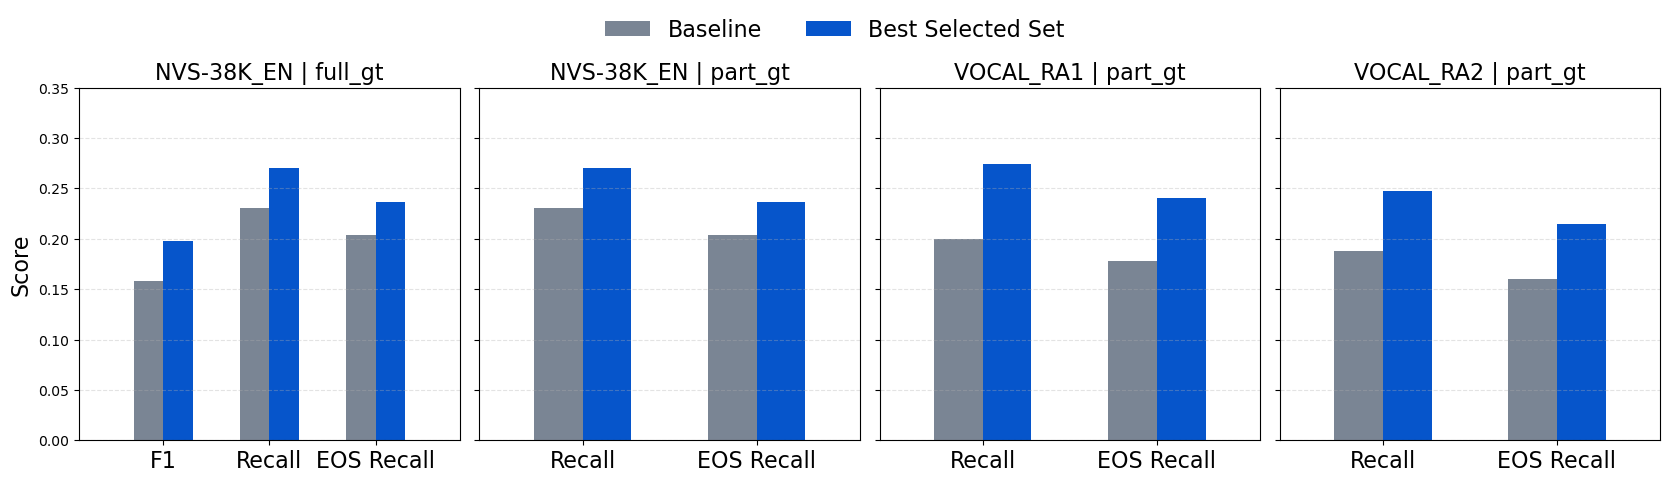

In [6]:
from evaluation.rq_plots import plot_rq1_all_settings_grouped_bars

rq1_fig_all_settings = plot_rq1_all_settings_grouped_bars(
    rq1_tables["full_gt"],
    rq1_tables["part_gt"],
    setting_order=setting_order,
)
plt.show()

rq1_fig_all_settings_path = rq_results_dir / "rq1_capability_all_settings.png"

rq1_fig_all_settings.savefig(
    rq1_fig_all_settings_path,
    dpi=300,
    bbox_inches="tight"
)


## RQ2 Ranking Configuration: Single best

In [7]:
from evaluation.analysis_tables import build_rq2a_single_ranking_tables

rq2a_single_all = pd.concat(
    [
        bundle["results"]["rq2a_single"]
        for bundle in analysis_bundle["bundles_by_spec"].values()
    ],
    ignore_index=True,
)

rq2a_single_tables_top_5 = build_rq2a_single_ranking_tables(
    rq2a_single_all,
    top_k=5,
)

print("RQ2 Sensitivity to Configuration Changes: Single Configuration Ranking Tables:")
for setting_name, df_table in rq2a_single_tables_top_5.items():
    print(f"\n=== {setting_name} ===")
    display(df_table.round(3))

RQ2 Sensitivity to Configuration Changes: Single Configuration Ranking Tables:

=== NVS-38K_EN | full_gt ===


,Rank,VAD Mask,ASR Audio Input,F1,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,1,std_vocals,std_vocals_norm,0.193,0.260,0.228,0.228,1.484
1,2,std_vocals_norm,std_vocals_norm,0.189,0.258,0.226,0.226,1.495
2,3,std,std_vocals_norm,0.183,0.250,0.219,0.219,1.495
3,4,original,std_vocals_norm,0.182,0.247,0.216,0.216,1.480
4,5,original,std,0.161,0.233,0.205,0.205,1.532



=== NVS-38K_EN | part_gt ===


,Rank,VAD Mask,ASR Audio Input,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,1,std_vocals,std_vocals_norm,0.260,0.228,0.228,1.484
1,2,std_vocals_norm,std_vocals_norm,0.258,0.226,0.226,1.495
2,3,std,std_vocals_norm,0.250,0.219,0.219,1.495
3,4,original,std_vocals_norm,0.247,0.216,0.216,1.480
4,5,std_vocals,std_vocals,0.237,0.211,0.211,1.510



=== VOCAL_RA1 | part_gt ===


,Rank,VAD Mask,ASR Audio Input,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,1,std_vocals_norm,std,0.236,0.207,0.401,1.758
1,2,std_vocals_norm,original,0.232,0.204,0.395,1.694
2,3,std_vocals_norm,std_vocals_norm,0.220,0.192,0.386,1.857
3,4,std_vocals,std,0.220,0.192,0.383,1.728
4,5,std_vocals,original,0.216,0.190,0.378,1.669



=== VOCAL_RA2 | part_gt ===


,Rank,VAD Mask,ASR Audio Input,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,1,std,std,0.197,0.170,0.253,4.399
1,2,original,std,0.194,0.166,0.257,5.232
2,3,original,original,0.187,0.160,0.256,5.255
3,4,std,original,0.184,0.158,0.241,5.588
4,5,std_vocals,std,0.171,0.149,0.257,3.076


In [8]:
# save full RQ2a single-ranking tables (all 42) to one Excel workbook
rq2a_ranking_path = results_dir / "rq2_sensitivity_configuration_ranking_appendix_tables.xlsx"

rq2a_single_tables_all = build_rq2a_single_ranking_tables(
    rq2a_single_all,
    top_k=42,
)

with pd.ExcelWriter(rq2a_ranking_path, engine="openpyxl") as writer:
    for setting_name, df_table in rq2a_single_tables_all.items():
        sheet_name = setting_name.replace(" | ", "_")[:31]
        df_export = df_table.round(3).copy()

        df_export.to_excel(writer, sheet_name=sheet_name, index=False)

        worksheet = writer.sheets[sheet_name]

        for col_idx, col_name in enumerate(df_export.columns, 1):
            # only format float columns (skip int like Rank)
            if pd.api.types.is_float_dtype(df_export[col_name]):
                for row in range(2, len(df_export) + 2):
                    worksheet.cell(row=row, column=col_idx).number_format = "0.000"

print(rq2a_ranking_path)

/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq2_sensitivity_configuration_ranking_appendix_tables.xlsx


In [9]:
rq2_top5_clean = {}

for setting_name, df in rq2a_single_tables_top_5.items():
    df_clean = df[["Rank", "VAD Mask", "ASR Audio Input"]].copy()
    rq2_top5_clean[setting_name] = df_clean

for setting_name, df in rq2_top5_clean.items():
    print(f"\n=== {setting_name} ===")
    display(df.style.hide(axis="index").set_properties(**{"text-align": "center"}))


=== NVS-38K_EN | full_gt ===


Rank,VAD Mask,ASR Audio Input
1,std_vocals,std_vocals_norm
2,std_vocals_norm,std_vocals_norm
3,std,std_vocals_norm
4,original,std_vocals_norm
5,original,std



=== NVS-38K_EN | part_gt ===


Rank,VAD Mask,ASR Audio Input
1,std_vocals,std_vocals_norm
2,std_vocals_norm,std_vocals_norm
3,std,std_vocals_norm
4,original,std_vocals_norm
5,std_vocals,std_vocals



=== VOCAL_RA1 | part_gt ===


Rank,VAD Mask,ASR Audio Input
1,std_vocals_norm,std
2,std_vocals_norm,original
3,std_vocals_norm,std_vocals_norm
4,std_vocals,std
5,std_vocals,original



=== VOCAL_RA2 | part_gt ===


Rank,VAD Mask,ASR Audio Input
1,std,std
2,original,std
3,original,original
4,std,original
5,std_vocals,std


In [10]:
# save RQ2 top-5 configuration tables to one Excel workbook
rq2_top5_path = rq_results_dir / "rq2_sensitivity_configuration_ranking_top5_table.xlsx"

with pd.ExcelWriter(rq2_top5_path, engine="openpyxl") as writer:
    for setting_name, df in rq2_top5_clean.items():
        sheet_name = setting_name[:31]  # Excel limit for sheet names
        df_export = df.copy()
        df_export.to_excel(writer, sheet_name=sheet_name, index=False)

print(rq2_top5_path)

/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq2_sensitivity_configuration_ranking_top5_table.xlsx


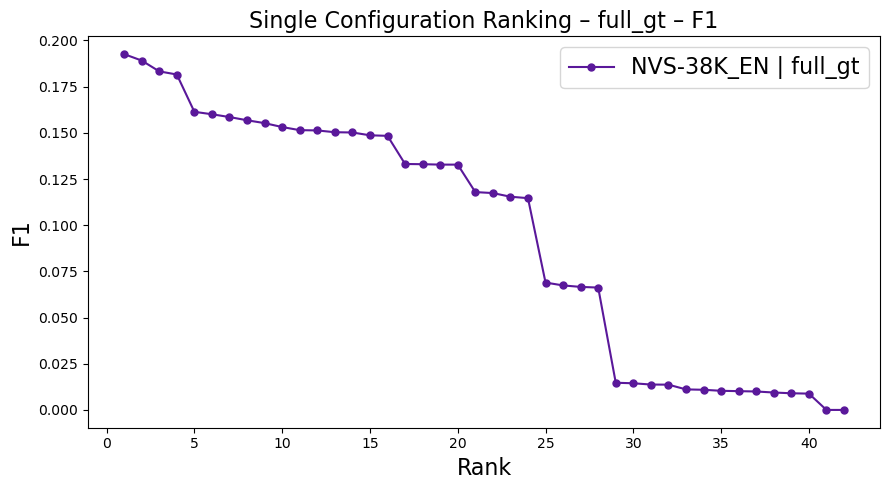

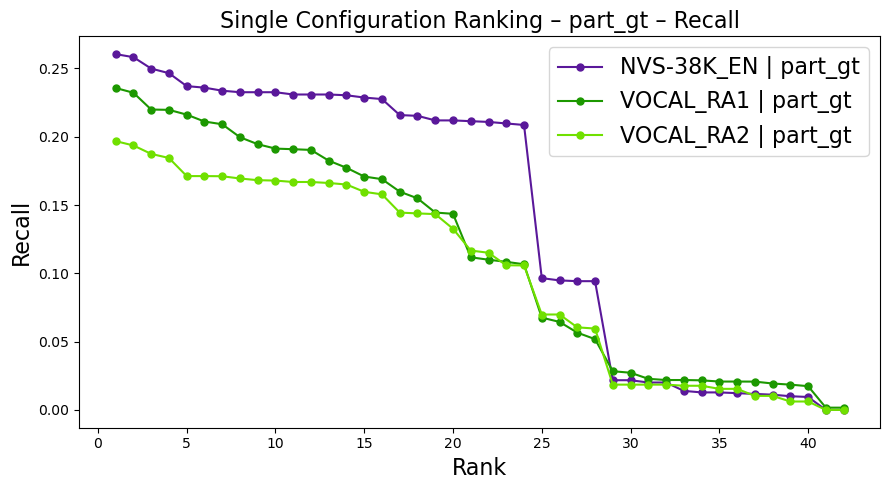

In [11]:

from evaluation.rq_plots import plot_rq2a_rank_vs_score

fig_full_gt = plot_rq2a_rank_vs_score(
    rq2a_single_all,
    mode="full_gt",
    score_col="macro_mean_f1",
    top_k=42,
    setting_order=setting_order,
)
plt.show()


fig_part_gt = plot_rq2a_rank_vs_score(
    rq2a_single_all,
    mode="part_gt",
    score_col="macro_mean_recall",
    top_k=42,
    setting_order=setting_order,
)
plt.show()


In [12]:
# save full RQ2a single-ranking tables (top 42) to png files
rq2_fig_path = results_dir
rq2_fig_full_gt = rq2_fig_path / "rq2_sensitivity_configuration_rank_vs_score_full_gt.png"
rq2_fig_part_gt = rq2_fig_path / "rq2_sensitivity_configuration_rank_vs_score_part_gt.png"

fig_full_gt.savefig(
    rq2_fig_full_gt,
    dpi=300,
    bbox_inches="tight"
)

fig_part_gt.savefig(
    rq2_fig_part_gt,
    dpi=300,
    bbox_inches="tight"
)

## RQ2 Configuration Combination: Selected Set

### Find k: Full-GT greedy forward union of complementary configurations

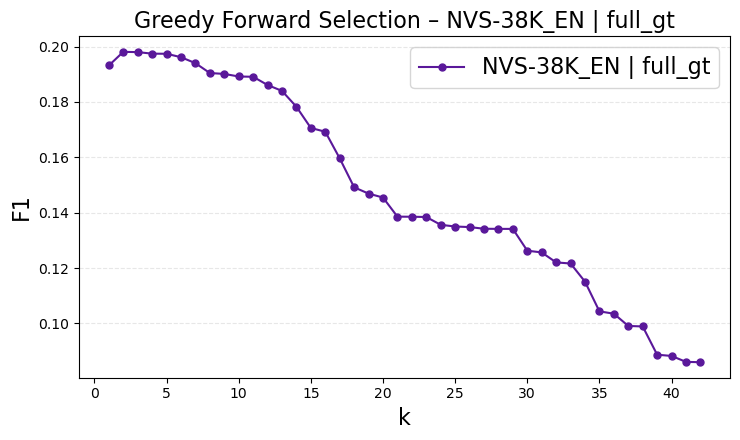

In [13]:
from evaluation.rq_plots import plot_rq2a_f1_vs_k

df_f1_vs_k = bundles_by_spec["NVS-38K_EN | full_gt"]["results"]["rq2a_f1_vs_k"]

f1_vs_k_fig = plot_rq2a_f1_vs_k(
    df_f1_vs_k,
    setting="NVS-38K_EN | full_gt",
)

plt.show()

In [14]:
# save full RQ2a single-ranking tables (top 42) to one Excel workbook
rq2_fig_path = results_dir
rq2_f1_vs_k_path = rq2_fig_path / "rq2_sensitivity_configuration_f1_vs_k.png"

f1_vs_k_fig.savefig(
    rq2_f1_vs_k_path,
    dpi=300,
    bbox_inches="tight"
)


### Delta Best Single Configuration vs. Best Selected Set

In [15]:
from evaluation.analysis_tables import build_rq2a_selected_set_tables

rq2a_selected_all = pd.concat(
    [
        bundle["results"]["rq2a_selected_set"]
        for bundle in analysis_bundle["bundles_by_spec"].values()
    ],
    ignore_index=True,
)

rq2a_selected_tables = build_rq2a_selected_set_tables(
    rq2a_single_all,
    rq2a_selected_all,
)

print("RQ2 Sensitivity to Configuration Changes: Combination of complimentary configurations (selected Set):")
for setting_name, df_table in rq2a_selected_tables.items():
    print(f"\n=== {setting_name} ===")
    display(df_table)

RQ2 Sensitivity to Configuration Changes: Combination of complimentary configurations (selected Set):

=== NVS-38K_EN | full_gt ===


,Setting,System,k,Config / Selected Set,F1,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,NVS-38K_EN | full_gt,Best Single,1,std_vocals + std_vocals_norm,0.192599,0.260457,0.227950,0.227950,1.484105
1,NVS-38K_EN | full_gt,Best Selected Set,2,"[""std_vocals_vad_std_vocals_norm_asr_nlp_nvv"",...",0.198103,0.270496,0.237039,0.237039,1.517568
2,NVS-38K_EN | full_gt,Δ vs Best Single,1,None,0.005504,0.010039,0.009089,0.009089,0.033463



=== NVS-38K_EN | part_gt ===


,Setting,System,k,Config / Selected Set,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,NVS-38K_EN | part_gt,Best Single,1,std_vocals + std_vocals_norm,0.260457,0.227950,0.227950,1.484105
1,NVS-38K_EN | part_gt,Best Selected Set,2,"[""std_vocals_vad_std_vocals_norm_asr_nlp_nvv"",...",0.270496,0.237039,0.237039,1.517568
2,NVS-38K_EN | part_gt,Δ vs Best Single,1,None,0.010039,0.009089,0.009089,0.033463



=== VOCAL_RA1 | part_gt ===


,Setting,System,k,Config / Selected Set,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,VOCAL_RA1 | part_gt,Best Single,1,std_vocals_norm + std,0.235670,0.206734,0.400543,1.758203
1,VOCAL_RA1 | part_gt,Best Selected Set,3,"[""std_vocals_norm_vad_std_asr_nlp_nvv"", ""std_v...",0.274072,0.240137,0.458683,3.098171
2,VOCAL_RA1 | part_gt,Δ vs Best Single,2,None,0.038402,0.033403,0.058140,1.339969



=== VOCAL_RA2 | part_gt ===


,Setting,System,k,Config / Selected Set,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,VOCAL_RA2 | part_gt,Best Single,1,std + std,0.196781,0.169956,0.253310,4.398920
1,VOCAL_RA2 | part_gt,Best Selected Set,3,"[""std_vad_std_asr_nlp_nvv"", ""std_vocals_vad_st...",0.247310,0.214327,0.329348,6.093335
2,VOCAL_RA2 | part_gt,Δ vs Best Single,2,None,0.050529,0.044372,0.076038,1.694415


## RQ2 Audio Derivative Aggregation

In [16]:
from evaluation.analysis_tables import build_derivative_matrix
# RQ2 Audio Derivative Aggregation - Just for inspection, not for final presentation. ToDo: update artifact with insertion rate and remove precision and f1 for part_gt
# Keep derivative matrices separated by metric / mode
derivative_matrix_f1 = build_derivative_matrix(
    views["derivative_comparison"][
        views["derivative_comparison"]["mode"] == "full_gt"
    ],
    value_col="macro_mean_f1", #toDo: also recall and dice
)

derivative_matrix_recall = build_derivative_matrix(
    views["derivative_comparison"][
        views["derivative_comparison"]["mode"] == "part_gt"
    ],
    value_col="macro_mean_recall", #toDo also eos and eos_tp and insertion_rate
)

print("\nDerivative Matrix (F1, full_gt):")
display(derivative_matrix_f1)
print("\nDerivative Matrix (Recall, part_gt):")
display(derivative_matrix_recall)




Derivative Matrix (F1, full_gt):


setting,audio_derivative_group,NVS-38K_EN | full_gt
0,all_derivatives,0.095108
1,background_like,0.074015
2,original_like,0.100977
3,vocals_like,0.110334



Derivative Matrix (Recall, part_gt):


setting,audio_derivative_group,NVS-38K_EN | part_gt,VOCAL_RA1 | part_gt,VOCAL_RA2 | part_gt
0,all_derivatives,0.144092,0.113201,0.100098
1,background_like,0.124412,0.079912,0.074329
2,original_like,0.151103,0.135523,0.117124
3,vocals_like,0.156760,0.124169,0.108839


In [17]:
# RQ2b Audio Derivative Aggregation - Group Comparison (Thesis Tables)
from evaluation.analysis_tables import build_rq2b_derivative_tables
## RQ2b Audio Derivative Aggregation

rq2b_tables = build_rq2b_derivative_tables(views["derivative_comparison"])

print("RQ2b Audio Derivative Table (Full-GT):")
display(rq2b_tables["full_gt"])

print("RQ2b Audio Derivative Table (Part-GT):")
display(rq2b_tables["part_gt"])

RQ2b Audio Derivative Table (Full-GT):


,Setting,Audio Derivative,F1,Recall,EOS Recall,Mean EOS TP,Insertion Rate,Best Config (VAD Mask + ASR Audio Input)
0,NVS-38K_EN | full_gt,original_like,0.100977,0.151103,0.133869,0.133869,1.152737,original + std
1,NVS-38K_EN | full_gt,vocals_like,0.110334,0.156760,0.137740,0.137740,1.138276,std_vocals + std_vocals_norm
2,NVS-38K_EN | full_gt,background_like,0.074015,0.124412,0.109291,0.109291,1.312246,std_vocals + std_background_norm
3,NVS-38K_EN | full_gt,all_derivatives,0.095108,0.144092,0.126966,0.126966,1.201086,std_vocals + std_vocals_norm


RQ2b Audio Derivative Table (Part-GT):


,Setting,Audio Derivative,Recall,EOS Recall,Mean EOS TP,Insertion Rate,Best Config (VAD Mask + ASR Audio Input)
0,NVS-38K_EN | part_gt,original_like,0.151103,0.133869,0.133869,1.152737,std_vocals + std
1,VOCAL_RA1 | part_gt,original_like,0.135523,0.119988,0.241753,1.366220,std_vocals_norm + std
2,VOCAL_RA2 | part_gt,original_like,0.117124,0.101574,0.163378,2.991855,std + std
3,NVS-38K_EN | part_gt,vocals_like,0.156760,0.137740,0.137740,1.138276,std_vocals + std_vocals_norm
4,VOCAL_RA1 | part_gt,vocals_like,0.124169,0.109210,0.231054,1.463313,std_vocals_norm + std_vocals_norm
5,VOCAL_RA2 | part_gt,vocals_like,0.108839,0.094015,0.149971,3.592042,std_vocals + std_vocals_norm
6,NVS-38K_EN | part_gt,background_like,0.124412,0.109291,0.109291,1.312246,std_vocals + std_background
7,VOCAL_RA1 | part_gt,background_like,0.079912,0.070488,0.164200,1.664332,std_vocals_norm + std_background_norm
8,VOCAL_RA2 | part_gt,background_like,0.074329,0.066837,0.108206,2.554865,std + std_background
9,NVS-38K_EN | part_gt,all_derivatives,0.144092,0.126966,0.126966,1.201086,std_vocals + std_vocals_norm


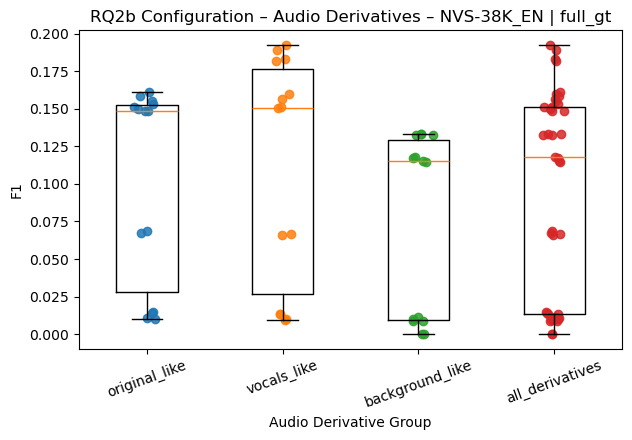

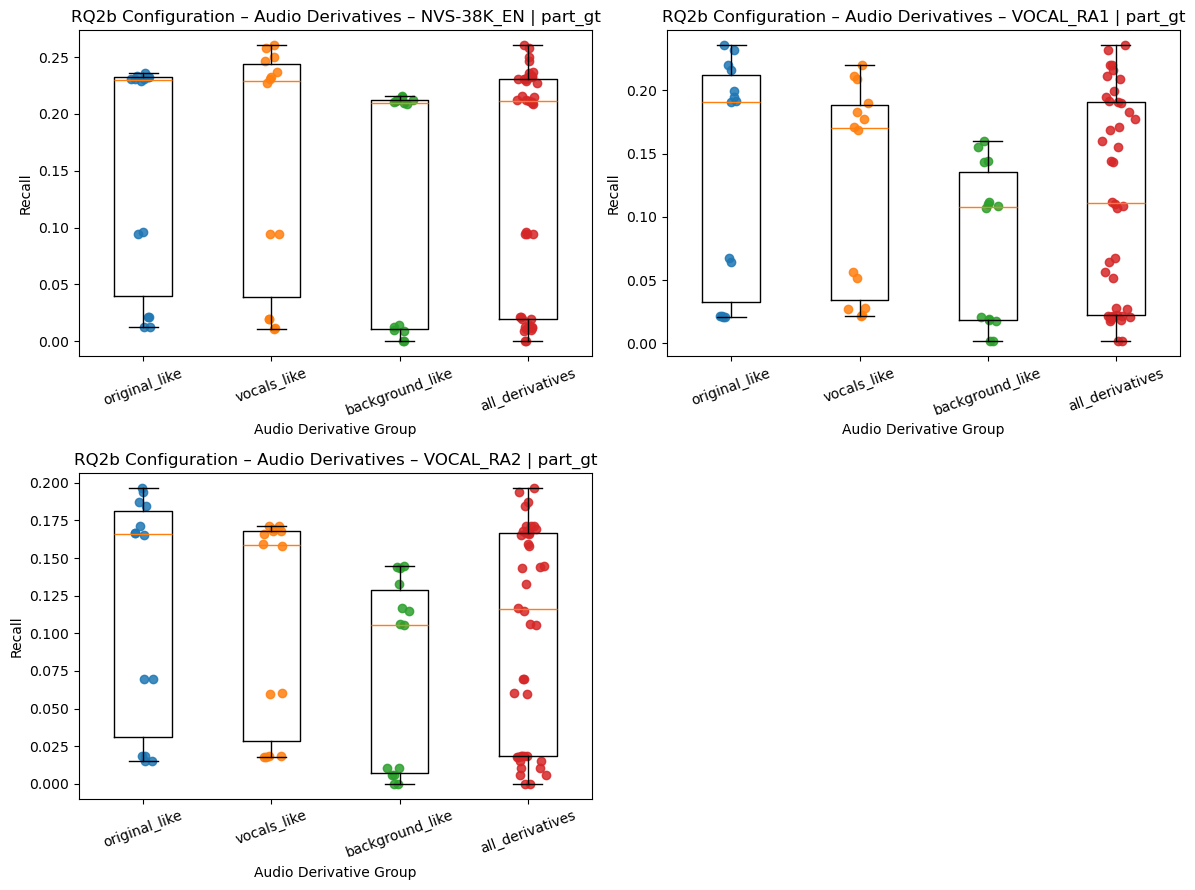

In [18]:
from evaluation.rq_plots import plot_rq2b_boxplot_with_points
fig = plot_rq2b_boxplot_with_points(
    rq2a_single_all,
    mode="full_gt",
    score_col="macro_mean_f1",
    top_k=None,
    setting_order=setting_order,
)
plt.show()

fig = plot_rq2b_boxplot_with_points(
    rq2a_single_all,
    mode="part_gt",
    score_col="macro_mean_recall",
    top_k=None,
    setting_order=setting_order,
)
plt.show()

## RQ2b Inspection of top 2

In [19]:
from evaluation.analysis_tables import inspect_top_n_rq2a_configs_by_group

df_top2_derivatives_full = inspect_top_n_rq2a_configs_by_group(
    rq2a_single_all,
    mode="full_gt",
    group_by="audio_derivative_group",
    top_n=2,
    setting_order=setting_order,
)
display(df_top2_derivatives_full)

df_top2_derivatives_part = inspect_top_n_rq2a_configs_by_group(
    rq2a_single_all,
    mode="part_gt",
    group_by="audio_derivative_group",
    top_n=2,
    setting_order=setting_order,
)
display(df_top2_derivatives_part)

,setting,audio_derivative_group,combo_key,vad_mask,asr_audio_in,macro_mean_f1,macro_mean_recall,macro_mean_dice_eos_recall,macro_mean_mean_dice_eos_tp,macro_mean_insertion_rate,rank_within_run
0,NVS-38K_EN | full_gt,background_like,std_vocals_vad_std_background_norm_asr_nlp_nvv,std_vocals,std_background_norm,0.133125,0.211935,0.185948,0.185948,1.767429,17
1,NVS-38K_EN | full_gt,background_like,std_vocals_norm_vad_std_background_norm_asr_nl...,std_vocals_norm,std_background_norm,0.133016,0.210820,0.185117,0.185117,1.761852,18
2,NVS-38K_EN | full_gt,original_like,original_vad_std_asr_nlp_nvv,original,std,0.161367,0.232571,0.204774,0.204774,1.531511,5
3,NVS-38K_EN | full_gt,original_like,original_vad_original_asr_nlp_nvv,original,original,0.158532,0.230898,0.203614,0.203614,1.520915,7
4,NVS-38K_EN | full_gt,vocals_like,std_vocals_vad_std_vocals_norm_asr_nlp_nvv,std_vocals,std_vocals_norm,0.192599,0.260457,0.227950,0.227950,1.484105,1
5,NVS-38K_EN | full_gt,vocals_like,std_vocals_norm_vad_std_vocals_norm_asr_nlp_nvv,std_vocals_norm,std_vocals_norm,0.189115,0.258226,0.226216,0.226216,1.495259,2


,setting,audio_derivative_group,combo_key,vad_mask,asr_audio_in,macro_mean_recall,macro_mean_dice_eos_recall,macro_mean_mean_dice_eos_tp,macro_mean_insertion_rate,rank_within_run
0,NVS-38K_EN | part_gt,background_like,std_vocals_vad_std_background_asr_nlp_nvv,std_vocals,std_background,0.215839,0.189689,0.189689,2.309537,17
1,NVS-38K_EN | part_gt,background_like,std_vocals_norm_vad_std_background_asr_nlp_nvv,std_vocals_norm,std_background,0.215282,0.189520,0.189520,2.308422,18
2,NVS-38K_EN | part_gt,original_like,std_vocals_vad_std_asr_nlp_nvv,std_vocals,std,0.235917,0.210177,0.210177,1.524261,6
3,NVS-38K_EN | part_gt,original_like,std_vocals_vad_original_asr_nlp_nvv,std_vocals,original,0.233687,0.208438,0.208438,1.511991,7
4,NVS-38K_EN | part_gt,vocals_like,std_vocals_vad_std_vocals_norm_asr_nlp_nvv,std_vocals,std_vocals_norm,0.260457,0.227950,0.227950,1.484105,1
5,NVS-38K_EN | part_gt,vocals_like,std_vocals_norm_vad_std_vocals_norm_asr_nlp_nvv,std_vocals_norm,std_vocals_norm,0.258226,0.226216,0.226216,1.495259,2
6,VOCAL_RA1 | part_gt,background_like,std_vocals_norm_vad_std_background_norm_asr_nl...,std_vocals_norm,std_background_norm,0.159783,0.139697,0.313792,2.628160,17
7,VOCAL_RA1 | part_gt,background_like,std_vocals_norm_vad_std_background_asr_nlp_nvv,std_vocals_norm,std_background,0.154889,0.136033,0.297520,2.676850,18
8,VOCAL_RA1 | part_gt,original_like,std_vocals_norm_vad_std_asr_nlp_nvv,std_vocals_norm,std,0.235670,0.206734,0.400543,1.758203,1
9,VOCAL_RA1 | part_gt,original_like,std_vocals_norm_vad_original_asr_nlp_nvv,std_vocals_norm,original,0.232170,0.203808,0.394814,1.693515,2


## Configuration VAD Mask Inspection

In [20]:
from evaluation.analysis_tables import build_rq2b_vad_mask_tables

rq2b_vad_tables = build_rq2b_vad_mask_tables(
    rq2a_single_all,
    setting_order=setting_order,
)

display(rq2b_vad_tables["full_gt"])
display(rq2b_vad_tables["part_gt"])

,Setting,VAD Mask,F1,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,NVS-38K_EN | full_gt,no,0.044861,0.063302,0.053828,0.053828,0.968953
1,NVS-38K_EN | full_gt,original,0.151491,0.226436,0.199012,0.199012,1.680889
2,NVS-38K_EN | full_gt,std,0.146982,0.226715,0.200337,0.200337,1.679494
3,NVS-38K_EN | full_gt,std_background,0.009754,0.011247,0.010067,0.010067,0.078732
4,NVS-38K_EN | full_gt,std_background_norm,0.012974,0.018405,0.016491,0.016491,0.620468
5,NVS-38K_EN | full_gt,std_vocals,0.151469,0.232478,0.205471,0.205471,1.684514
6,NVS-38K_EN | full_gt,std_vocals_norm,0.148227,0.230061,0.203560,0.203560,1.694553


,Setting,VAD Mask,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,NVS-38K_EN | part_gt,no,0.063302,0.053828,0.053828,0.968953
1,NVS-38K_EN | part_gt,original,0.226436,0.199012,0.199012,1.680889
2,NVS-38K_EN | part_gt,std,0.226715,0.200337,0.200337,1.679494
3,NVS-38K_EN | part_gt,std_background,0.011247,0.010067,0.010067,0.078732
4,NVS-38K_EN | part_gt,std_background_norm,0.018405,0.016491,0.016491,0.620468
5,NVS-38K_EN | part_gt,std_vocals,0.232478,0.205471,0.205471,1.684514
6,NVS-38K_EN | part_gt,std_vocals_norm,0.230061,0.203560,0.203560,1.694553
7,VOCAL_RA1 | part_gt,no,0.040623,0.034930,0.085893,1.179916
8,VOCAL_RA1 | part_gt,original,0.161528,0.143790,0.304820,2.119849
9,VOCAL_RA1 | part_gt,std,0.157225,0.139677,0.289121,2.142676


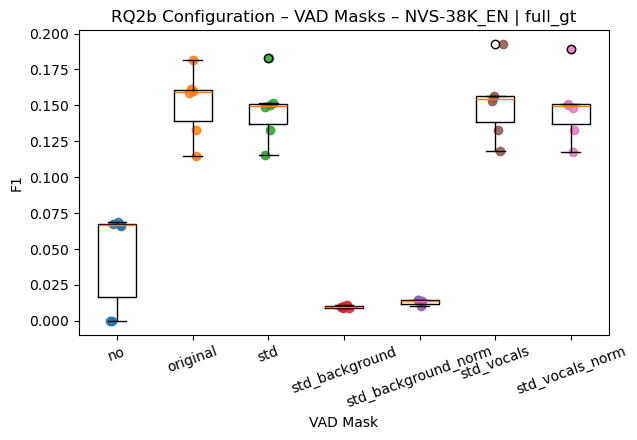

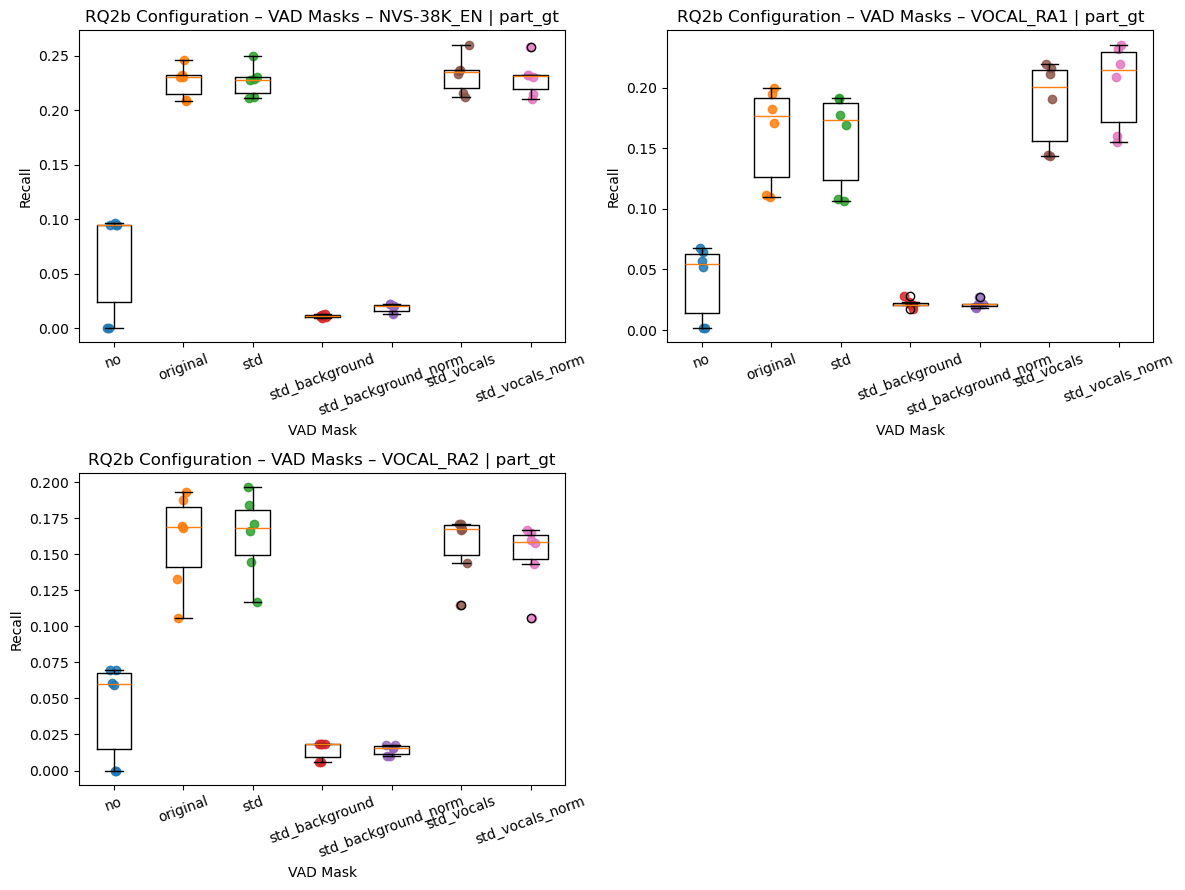

In [21]:
from evaluation.rq_plots import plot_rq2b_vad_mask_boxplot_with_points

fig = plot_rq2b_vad_mask_boxplot_with_points(
    rq2a_single_all,
    mode="full_gt",
    score_col="macro_mean_f1",
    top_k=None,
    setting_order=setting_order,
)
plt.show()

fig = plot_rq2b_vad_mask_boxplot_with_points(
    rq2a_single_all,
    mode="part_gt",
    score_col="macro_mean_recall",
    top_k=None,
    setting_order=setting_order,
)
plt.show()

In [22]:
df_top2_vad_full = inspect_top_n_rq2a_configs_by_group(
    rq2a_single_all,
    mode="full_gt",
    group_by="vad_mask",
    top_n=2,
    setting_order=setting_order,
)
display(df_top2_vad_full)

df_top2_vad_part = inspect_top_n_rq2a_configs_by_group(
    rq2a_single_all,
    mode="part_gt",
    group_by="vad_mask",
    top_n=2,
    setting_order=setting_order,
)
display(df_top2_vad_part)

,setting,vad_mask,combo_key,vad_mask,asr_audio_in,macro_mean_f1,macro_mean_recall,macro_mean_dice_eos_recall,macro_mean_mean_dice_eos_tp,macro_mean_insertion_rate,rank_within_run
0,NVS-38K_EN | full_gt,no,no_vad_original_asr_nlp_nvv,no,original,0.068944,0.096486,0.082422,0.082422,1.396542,25
1,NVS-38K_EN | full_gt,no,no_vad_std_asr_nlp_nvv,no,std,0.067394,0.094255,0.080437,0.080437,1.394311,26
2,NVS-38K_EN | full_gt,original,original_vad_std_vocals_norm_asr_nlp_nvv,original,std_vocals_norm,0.181569,0.246514,0.216277,0.216277,1.480201,4
3,NVS-38K_EN | full_gt,original,original_vad_std_asr_nlp_nvv,original,std,0.161367,0.232571,0.204774,0.204774,1.531511,5
4,NVS-38K_EN | full_gt,std,std_vad_std_vocals_norm_asr_nlp_nvv,std,std_vocals_norm,0.183257,0.249861,0.218978,0.218978,1.494702,3
5,NVS-38K_EN | full_gt,std,std_vad_std_asr_nlp_nvv,std,std,0.151447,0.230898,0.205536,0.205536,1.519241,11
6,NVS-38K_EN | full_gt,std_background,std_background_vad_original_asr_nlp_nvv,std_background,original,0.010913,0.012828,0.011515,0.011515,0.060234,34
7,NVS-38K_EN | full_gt,std_background,std_background_vad_std_asr_nlp_nvv,std_background,std,0.010355,0.012270,0.011013,0.011013,0.059119,35
8,NVS-38K_EN | full_gt,std_background_norm,std_background_norm_vad_std_asr_nlp_nvv,std_background_norm,std,0.014710,0.021751,0.019424,0.019424,0.517568,29
9,NVS-38K_EN | full_gt,std_background_norm,std_background_norm_vad_original_asr_nlp_nvv,std_background_norm,original,0.014432,0.021751,0.019393,0.019393,0.517568,30


,setting,vad_mask,combo_key,vad_mask,asr_audio_in,macro_mean_recall,macro_mean_dice_eos_recall,macro_mean_mean_dice_eos_tp,macro_mean_insertion_rate,rank_within_run
0,NVS-38K_EN | part_gt,no,no_vad_original_asr_nlp_nvv,no,original,0.096486,0.082422,0.082422,1.396542,25
1,NVS-38K_EN | part_gt,no,no_vad_std_vocals_asr_nlp_nvv,no,std_vocals,0.094813,0.080236,0.080236,1.376464,26
2,NVS-38K_EN | part_gt,original,original_vad_std_vocals_norm_asr_nlp_nvv,original,std_vocals_norm,0.246514,0.216277,0.216277,1.480201,4
3,NVS-38K_EN | part_gt,original,original_vad_std_asr_nlp_nvv,original,std,0.232571,0.204774,0.204774,1.531511,10
4,NVS-38K_EN | part_gt,std,std_vad_std_vocals_norm_asr_nlp_nvv,std,std_vocals_norm,0.249861,0.218978,0.218978,1.494702,3
5,NVS-38K_EN | part_gt,std,std_vad_std_asr_nlp_nvv,std,std,0.230898,0.205536,0.205536,1.519241,12
6,NVS-38K_EN | part_gt,std_background,std_background_vad_original_asr_nlp_nvv,std_background,original,0.012828,0.011515,0.011515,0.060234,35
7,NVS-38K_EN | part_gt,std_background,std_background_vad_std_asr_nlp_nvv,std_background,std,0.012270,0.011013,0.011013,0.059119,36
8,NVS-38K_EN | part_gt,std_background_norm,std_background_norm_vad_std_asr_nlp_nvv,std_background_norm,std,0.021751,0.019424,0.019424,0.517568,29
9,NVS-38K_EN | part_gt,std_background_norm,std_background_norm_vad_original_asr_nlp_nvv,std_background_norm,original,0.021751,0.019393,0.019393,0.517568,30


## RQ3 NVV Coverage

In [23]:
## RQ3 NVV Coverage

from evaluation.analysis_tables import (
    build_rq3_full_gt_label_tables,
    build_rq3_part_gt_event_tables,
    build_rq3_global_tables,
)

rq3_label_all = pd.concat(
    [
        bundle["results"]["rq3_label"]
        for bundle in analysis_bundle["bundles_by_spec"].values()
    ],
    ignore_index=True,
)

rq3_global_all = pd.concat(
    [
        bundle["results"]["rq3_global"]
        for bundle in analysis_bundle["bundles_by_spec"].values()
    ],
    ignore_index=True,
)

rq3_full_gt_label_tables = build_rq3_full_gt_label_tables(rq3_label_all)
rq3_part_gt_event_tables = build_rq3_part_gt_event_tables(rq3_label_all)
rq3_global_tables = build_rq3_global_tables(rq3_global_all)



## RQ3 Global Metrics Tables - Full-GT and Part-GT

In [24]:
display(rq3_global_tables["full_gt"])
display(rq3_global_tables["part_gt"])

,Setting,n_gt_events_total,tp_total,fn_total,insertions_total,F1,Recall,EOS Recall,Mean EOS TP,Insertion Rate,Deletion Rate
0,NVS-38K_EN | full_gt,1793,485,1308,2721,0.194039,0.270496,0.237039,0.876311,1.517568,0.729504


,Setting,n_gt_events_total,tp_total,fn_total,insertions_total,Recall,EOS Recall,Mean EOS TP,Insertion Rate,Deletion Rate
0,NVS-38K_EN | part_gt,1793,485,1308,2721,0.270496,0.237039,0.876311,1.517568,0.729504
1,VOCAL_RA1 | part_gt,501,124,377,1323,0.247505,0.217379,0.878282,2.640719,0.752495
2,VOCAL_RA2 | part_gt,332,76,256,1554,0.228916,0.196840,0.859882,4.680723,0.771084


## RQ3 Label Coverage (Full-GT) Table and Plot

In [25]:
print("RQ3 Event Tables (Full-GT):")
for setting_name, df_table in rq3_full_gt_label_tables.items():
    print(f"\n=== {setting_name} ===")
    display(df_table)

RQ3 Event Tables (Full-GT):

=== NVS-38K_EN | full_gt ===


,Setting,Label,n_gt_events,tp,fn,Recall,EOS Recall,Mean EOS TP,Mean Overlap (s)
0,NVS-38K_EN | full_gt,sigh,307,118,189,0.384365,0.349987,0.910559,0.644008
1,NVS-38K_EN | full_gt,gasp,34,13,21,0.382353,0.348971,0.912692,0.547769
2,NVS-38K_EN | full_gt,throatclearing,486,154,332,0.316872,0.265599,0.838188,0.370727
3,NVS-38K_EN | full_gt,yawn,17,5,12,0.294118,0.280824,0.954800,0.881800
4,NVS-38K_EN | full_gt,sniff,117,27,90,0.230769,0.204145,0.884630,0.378479
5,NVS-38K_EN | full_gt,coughing,400,89,311,0.222500,0.192048,0.863135,0.407181
6,NVS-38K_EN | full_gt,crying,37,8,29,0.216216,0.191432,0.885375,0.851375
7,NVS-38K_EN | full_gt,breath,74,16,58,0.216216,0.183473,0.848562,0.527187
8,NVS-38K_EN | full_gt,laughing,309,53,256,0.171521,0.157168,0.916321,0.947244
9,NVS-38K_EN | full_gt,snore,12,2,10,0.166667,0.159667,0.958000,0.842500


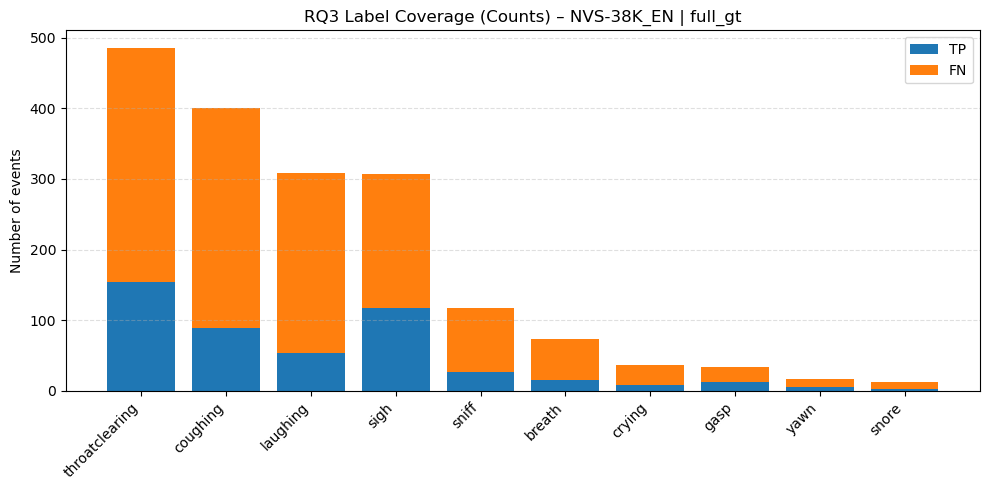

In [26]:
from evaluation.rq_plots import plot_rq3_label_coverage

fig = plot_rq3_label_coverage(
    rq3_full_gt_label_tables["NVS-38K_EN | full_gt"],
    setting=None,
)
plt.show()


## RQ3 Label quality (full-GT)

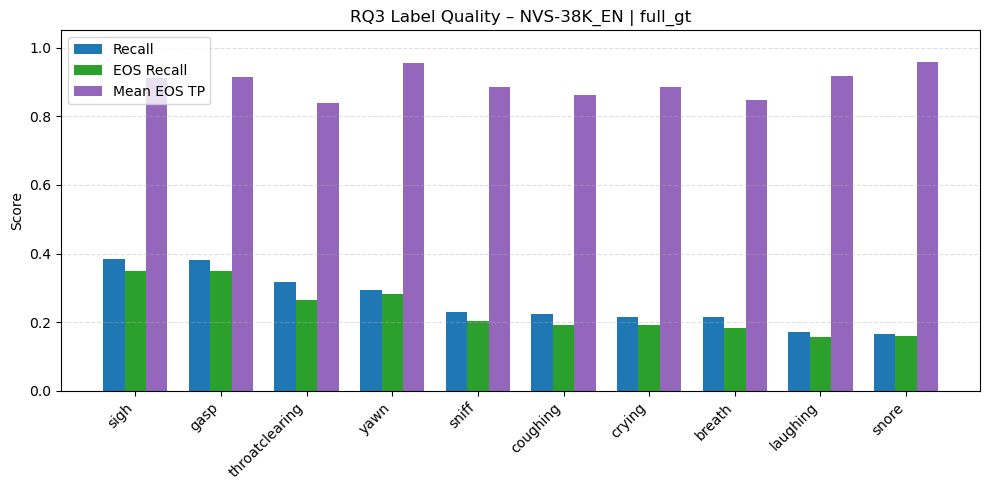

In [27]:
from evaluation.rq_plots import plot_rq3_label_quality

fig = plot_rq3_label_quality(
    rq3_full_gt_label_tables["NVS-38K_EN | full_gt"]
)
plt.show()

## RQ3 Global Recall Comparison (Full-GT - Part-GT)

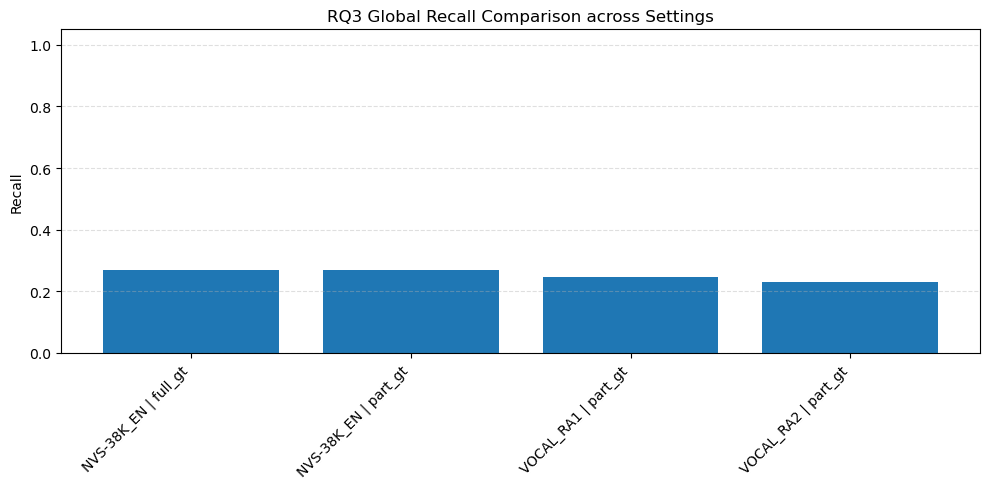

In [28]:
from evaluation.rq_plots import plot_rq3_global_recall_comparison

fig = plot_rq3_global_recall_comparison(
    rq3_global_all,
    setting_order=setting_order,
)
plt.show()

## RQ3 Event Samples (Part-GT) Tables

In [29]:
## RQ3 Event Samples (Part-GT) Tables
print("RQ3 Event Tables (Part-GT):")
for setting_name, df_table in rq3_part_gt_event_tables.items():
    print(f"\n=== {setting_name} ===")
    display(df_table)

RQ3 Event Tables (Part-GT):

=== NVS-38K_EN | part_gt ===


,Setting,Audio ID,GT Event ID,GT Label,Cand Event ID,Cand Label,Status,EOS,Overlap (s)
0,NVS-38K_EN | part_gt,nvs38k_00007,NVS_EN_000001,sigh,1,non_word (nlp): [UH],Hit,0.877,0.800
1,NVS-38K_EN | part_gt,nvs38k_00020,NVS_EN_000002,throatclearing,1,filler (nlp): Hmm.,Hit,0.880,0.627
2,NVS-38K_EN | part_gt,nvs38k_00130,NVS_EN_000008,sigh,1,filler (nlp): Ah.,Hit,0.870,0.420
3,NVS-38K_EN | part_gt,nvs38k_00174,NVS_EN_000010,throatclearing,1,filler (nlp): Huh.,Hit,0.872,0.316
4,NVS-38K_EN | part_gt,nvs38k_00223,NVS_EN_000013,laughing,1,nvv (vad_gap),Hit,0.948,1.067
...,...,...,...,...,...,...,...,...,...
4509,NVS-38K_EN | part_gt,nvs38k_38559,NaN,NaN,1,filler (nlp): Like,Insertion,NaN,NaN
4510,NVS-38K_EN | part_gt,nvs38k_38615,NaN,NaN,1,filler (nlp): Huh?,Insertion,NaN,NaN
4511,NVS-38K_EN | part_gt,nvs38k_38615,NaN,NaN,2,non_word (nlp): [UH],Insertion,NaN,NaN
4512,NVS-38K_EN | part_gt,nvs38k_38616,NaN,NaN,1,filler (nlp): Oh.,Insertion,NaN,NaN



=== VOCAL_RA1 | part_gt ===


,Setting,Audio ID,GT Event ID,GT Label,Cand Event ID,Cand Label,Status,EOS,Overlap (s)
0,VOCAL_RA1 | part_gt,-RoRyAeTlLY,a_RA1_721_05,um,6,non_word (nlp): [UM],Hit,0.885,0.580
1,VOCAL_RA1 | part_gt,-RoRyAeTlLY,a_RA1_721_06,um,8,non_word (nlp): [UM],Hit,0.855,0.543
2,VOCAL_RA1 | part_gt,-RoRyAeTlLY,a_RA1_721_08,uh,22,non_word (nlp): [UH],Hit,0.813,0.545
3,VOCAL_RA1 | part_gt,0O0QQkVKuFw,a_RA1_741_02,sigh,4,non_word (nlp): [UH],Hit,0.764,0.210
4,VOCAL_RA1 | part_gt,0O0QQkVKuFw,a_RA1_741_03,hey yell,8,"filler (nlp): Hey,",Hit,0.788,0.390
...,...,...,...,...,...,...,...,...,...
1819,VOCAL_RA1 | part_gt,z2BtmcDBC5s,NaN,NaN,6,"filler (nlp): Well,",Insertion,NaN,NaN
1820,VOCAL_RA1 | part_gt,zEsDardJXjg,NaN,NaN,1,filler (nlp): Okay.,Insertion,NaN,NaN
1821,VOCAL_RA1 | part_gt,zEsDardJXjg,NaN,NaN,2,filler (nlp): Yeah.,Insertion,NaN,NaN
1822,VOCAL_RA1 | part_gt,zEsDardJXjg,NaN,NaN,3,filler (nlp): Hmm.,Insertion,NaN,NaN



=== VOCAL_RA2 | part_gt ===


,Setting,Audio ID,GT Event ID,GT Label,Cand Event ID,Cand Label,Status,EOS,Overlap (s)
0,VOCAL_RA2 | part_gt,0CBI5294D10,a_RA2_028,snoring,2,nvv (vad_gap),Hit,0.955,1.388
1,VOCAL_RA2 | part_gt,0ZDqtg42pxY,a_RA2_032_01,grunting,4,"filler (nlp): oh,",Hit,0.844,0.460
2,VOCAL_RA2 | part_gt,1msGzgrd3Pw,a_RA1_771_01,exhale,1,oov (nlp): Felsen,Hit,0.912,1.163
3,VOCAL_RA2 | part_gt,1nHQZ3goq2o,a_RA2_035_02,ah sound,7,non_word (nlp): [UH],Hit,0.940,0.503
4,VOCAL_RA2 | part_gt,1nHQZ3goq2o,a_RA2_035_03,um sound,8,non_word (nlp): [UM],Hit,0.832,0.570
...,...,...,...,...,...,...,...,...,...
1881,VOCAL_RA2 | part_gt,ydAyvvDQrgY,NaN,NaN,12,nvv (vad_gap),Insertion,NaN,NaN
1882,VOCAL_RA2 | part_gt,ydAyvvDQrgY,NaN,NaN,13,filler (nlp): alright.,Insertion,NaN,NaN
1883,VOCAL_RA2 | part_gt,ydAyvvDQrgY,NaN,NaN,14,filler (nlp): Yeah.,Insertion,NaN,NaN
1884,VOCAL_RA2 | part_gt,ydAyvvDQrgY,NaN,NaN,15,"filler (nlp): Yeah,",Insertion,NaN,NaN


In [30]:
display(rq1_tables["full_gt"].columns)
display(rq2a_single_all.columns)
display(rq3_global_tables["full_gt"].columns)

Index(['Setting', 'System', 'F1', 'Recall', 'EOS Recall', 'Mean EOS TP',
       'Insertion Rate'],
      dtype='object')

Index(['setting', 'dataset_name', 'mode', 'combo_key', 'vad_mask',
       'asr_audio_in', 'n_audio_ids', 'macro_mean_n_gt', 'macro_mean_n_cand',
       'macro_mean_tp', 'macro_mean_fn', 'macro_mean_fp', 'macro_mean_recall',
       'macro_mean_precision', 'macro_mean_f1', 'macro_mean_mean_dice_eos_tp',
       'macro_mean_dice_eos_recall', 'macro_mean_mean_overlap_s_tp',
       'macro_mean_insertion_rate', 'macro_mean_deletion_rate',
       'macro_mean_error_rate', 'rank_within_run'],
      dtype='object')

Index(['Setting', 'n_gt_events_total', 'tp_total', 'fn_total',
       'insertions_total', 'F1', 'Recall', 'EOS Recall', 'Mean EOS TP',
       'Insertion Rate', 'Deletion Rate'],
      dtype='object')